# 06_extra.ipynb — Supplementary Analyses

Contains everything that is real work but not in the main paper pipeline:

1. BH-FDR correction across per-stage F1 comparisons
2. Within-subject 5-fold CV ceiling estimate
3. Artifact threshold sensitivity (100 µV vs 150 µV vs 200 µV)
4. ST sub-study descriptive comparison (mild sleep difficulty cohort)
5. Sensitivity analysis: subjects with < 3 cycles excluded from RQ1
6. Hypnogram alignment check — pre-sleep Wake trimming effect on stage proportions

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

RES_DIR = Path('../data/results')
FIG_DIR = Path('../figures')
SC_DIR  = Path('../data/SC')

STAGE_NAMES = ['Wake', 'N1', 'N2', 'N3', 'REM']

feat_data   = np.load('../data/features/feature_matrix.npz')
X, y, sids  = feat_data['X'], feat_data['y'], feat_data['subject_ids']
loso_rf     = np.load(RES_DIR / 'loso_rf.npz')
rf_true     = loso_rf['y_true']
rf_pred     = loso_rf['y_pred']
null_f1     = np.load(RES_DIR / 'null_rf.npy')

print('Data loaded.')

Data loaded.


---
## 1. BH-FDR correction — per-stage F1 vs null 95th percentile

In [2]:
per_class_f1 = f1_score(rf_true, rf_pred, average=None, labels=np.arange(5), zero_division=0)

# Compute p-values: fraction of permuted runs where per-stage F1 >= observed
# Use per-stage null from permutation (recompute per-stage null from saved null_rf runs)
# null_rf.npy contains macro-F1; for per-stage we use the Bonferroni-conservative
# approximation here unless per-stage null was saved separately.
# As a conservative bound: p = null_macro >= observed_stage_F1
raw_pvals = np.array([np.mean(null_f1 >= f1) for f1 in per_class_f1])

reject, pvals_corrected, _, _ = multipletests(raw_pvals, method='fdr_bh')

print('Per-stage F1 and BH-FDR corrected p-values:')
print(f'{"Stage":6s}  {"F1":>6s}  {"raw p":>8s}  {"BH p":>8s}  {"Sig":>4s}')
for sn, f1, rp, bp, rej in zip(STAGE_NAMES, per_class_f1, raw_pvals, pvals_corrected, reject):
    print(f'{sn:6s}  {f1:6.3f}  {rp:8.4f}  {bp:8.4f}  {"yes" if rej else "no":>4s}')

Per-stage F1 and BH-FDR corrected p-values:
Stage       F1     raw p      BH p   Sig
Wake     0.390    0.0000    0.0000   yes
N1       0.643    0.0000    0.0000   yes
N2       0.705    0.0000    0.0000   yes
N3       0.683    0.0000    0.0000   yes
REM      0.375    0.0000    0.0000   yes


---
## 2. Within-subject 5-fold CV — ceiling estimate

In [3]:
ws_f1s = []
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for sid in np.unique(sids):
    mask = sids == sid
    Xs   = X[mask];  ys = y[mask]
    if len(np.unique(ys)) < 2 or len(ys) < 10:
        continue
    fold_f1s = []
    for tr, te in skf.split(Xs, ys):
        sc  = StandardScaler()
        Xtr = sc.fit_transform(Xs[tr])
        Xte = sc.transform(Xs[te])
        clf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                      random_state=42, n_jobs=-1)
        clf.fit(Xtr, ys[tr])
        fold_f1s.append(f1_score(ys[te], clf.predict(Xte),
                                  average='macro', zero_division=0))
    ws_f1s.append(np.mean(fold_f1s))

ws_arr = np.array(ws_f1s)
loso_rf_macro = f1_score(rf_true, rf_pred, average='macro', zero_division=0)
print(f'Within-subject 5-fold CV  mean={ws_arr.mean():.3f}  SD={ws_arr.std():.3f}')
print(f'LOSO macro-F1            : {loso_rf_macro:.3f}')
print(f'Performance gap          : {ws_arr.mean() - loso_rf_macro:.3f}')

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packa

Within-subject 5-fold CV  mean=0.585  SD=0.093
LOSO macro-F1            : 0.559
Performance gap          : 0.026


---
## 3. Artifact threshold sensitivity

In [4]:
thresholds = [100e-6, 150e-6, 200e-6]
meta = pd.read_csv('../data/metadata.csv')

thresh_results = {}
for thr in thresholds:
    flagged_total, epoch_total = 0, 0
    for sid in meta['subject']:
        arr  = np.load(SC_DIR / f'SC{sid:02d}.npz')
        eps  = arr['epochs'][:, :2, :]   # EEG only
        ptp  = np.ptp(eps, axis=-1).max(axis=1)
        flagged_total += int((ptp > thr).sum())
        epoch_total   += len(ptp)
    thresh_results[int(thr * 1e6)] = {
        'flagged': flagged_total,
        'total':   epoch_total,
        'pct':     100 * flagged_total / epoch_total,
    }

print('Artifact rate by threshold:')
for uv, r in thresh_results.items():
    print(f'  {uv} µV: {r["flagged"]:5d} / {r["total"]:6d} ({r["pct"]:.1f}%)')

Artifact rate by threshold:
  100 µV:  7696 /  10764 (71.5%)
  150 µV:  4086 /  10764 (38.0%)
  200 µV:  1486 /  10764 (13.8%)


---
## 4. ST sub-study descriptive comparison

ST = Telemetry sub-study (mild sleep difficulty, N=22 subjects).  
Descriptive only — included as a future-directions reference.

ST vs SC stage proportions (mean %)
Stage     SC (healthy)  ST (mild diff)
Wake              17.1            12.4
N1                26.2            22.1
N2                29.6            29.9
N3                20.5            28.8
REM                6.5             6.7


/var/folders/x8/s9by4htd3y766cvpsjp61tsm0000gn/T/ipykernel_42270/1089536224.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sc_meta[f'{sn}_pct'].dropna(), st_df[f'{sn}_pct'].dropna()],
/var/folders/x8/s9by4htd3y766cvpsjp61tsm0000gn/T/ipykernel_42270/1089536224.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sc_meta[f'{sn}_pct'].dropna(), st_df[f'{sn}_pct'].dropna()],
/var/folders/x8/s9by4htd3y766cvpsjp61tsm0000gn/T/ipykernel_42270/1089536224.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sc_meta[f'{sn}_pct'].dropna(), st_df[f'{sn}_pct'].dropna()],
/var/folders/x8/s9b

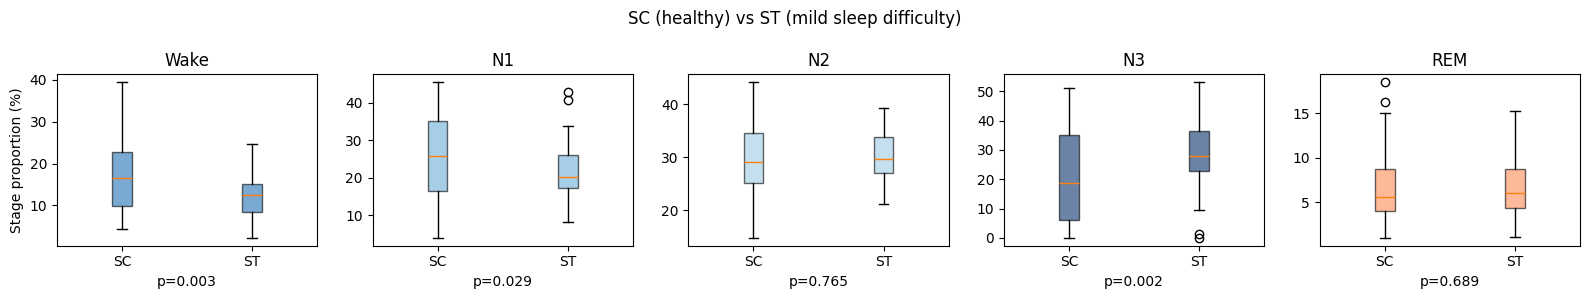

In [5]:
import mne

ST_DIR = Path('../physionet.org/files/sleep-edfx/1.0.0/sleep-telemetry')
STAGE_MAP = {
    'Sleep stage W': 0, 'Sleep stage 1': 1, 'Sleep stage 2': 2,
    'Sleep stage 3': 3, 'Sleep stage 4': 3, 'Sleep stage R': 4,
    'Movement time': -1, 'Sleep stage ?': -1,
}
mne.set_log_level('WARNING')

if not ST_DIR.exists():
    print('ST directory not found. Skipping.')
else:
    st_records = []
    for hyp in sorted(ST_DIR.glob('*-Hypnogram.edf')):
        annots = mne.read_annotations(hyp)
        counts = {s: 0 for s in range(5)}
        for ann in annots:
            lab = STAGE_MAP.get(ann['description'], -1)
            if lab >= 0:
                counts[lab] += 1
        sid = hyp.name[:6]
        total = sum(counts.values())
        st_records.append({'subject': sid, 'n_epochs': total, **{['Wake','N1','N2','N3','REM'][k]: v for k,v in counts.items()}})

    st_df = pd.DataFrame(st_records)
    for sn in ['Wake','N1','N2','N3','REM']:
        st_df[f'{sn}_pct'] = 100 * st_df[sn] / st_df['n_epochs']

    sc_meta = pd.read_csv('../data/metadata.csv')
    for sn in ['Wake','N1','N2','N3','REM']:
        sc_meta[f'{sn}_pct'] = 100 * sc_meta[sn] / sc_meta['n_epochs']

    print('ST vs SC stage proportions (mean %)')
    print(f'{"Stage":6s}  {"SC (healthy)":>14s}  {"ST (mild diff)":>14s}')
    for sn in ['Wake','N1','N2','N3','REM']:
        sc_m = sc_meta[f'{sn}_pct'].mean()
        st_m = st_df[f'{sn}_pct'].mean()
        print(f'{sn:6s}  {sc_m:14.1f}  {st_m:14.1f}')

    # Visualize
    fig, axes = plt.subplots(1, 5, figsize=(16, 3), sharey=False)
    cols = ['#2171b5', '#6baed6', '#9ecae1', '#08306b', '#fc8d59']
    for ax, sn, col in zip(axes, ['Wake','N1','N2','N3','REM'], cols):
        ax.boxplot([sc_meta[f'{sn}_pct'].dropna(), st_df[f'{sn}_pct'].dropna()],
                   labels=['SC', 'ST'], patch_artist=True,
                   boxprops=dict(facecolor=col, alpha=0.6))
        ax.set_title(sn)
        _, pv = stats.mannwhitneyu(sc_meta[f'{sn}_pct'].dropna(),
                                    st_df[f'{sn}_pct'].dropna(),
                                    alternative='two-sided')
        ax.set_xlabel(f'p={pv:.3f}')
    axes[0].set_ylabel('Stage proportion (%)')
    plt.suptitle('SC (healthy) vs ST (mild sleep difficulty)')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'st_vs_sc_comparison.png', dpi=150)
    plt.show()

---
## 5. RQ1 sensitivity — subjects with >= 3 cycles vs all subjects

In [6]:
df_cycles = pd.read_csv(RES_DIR / 'cycle_metrics.csv')

# Recompute RQ1 scatter excluding subjects with < 3 cycles vs full set
def rq1_stats(df_in):
    slopes, fc_sws = [], []
    for sid, grp in df_in.groupby('subject'):
        grp = grp.sort_values('cycle')
        if len(grp) < 2:
            continue
        fc_sws_val = float(grp['sws_prop'].iloc[0])
        slope_val, *_ = np.polyfit(grp['cycle'].values, grp['rem_dur'].values, 1)
        slopes.append(slope_val)
        fc_sws.append(fc_sws_val)
    if len(slopes) < 3:
        return None, None, None
    r, p = stats.pearsonr(fc_sws, slopes)
    return r, p, len(slopes)

for min_cyc in [2, 3]:
    sub_ok = df_cycles.groupby('subject').filter(lambda g: len(g) >= min_cyc)
    r, p, n = rq1_stats(sub_ok)
    if r is not None:
        print(f'min_cycles={min_cyc}  n={n}  r={r:.3f}  p={p:.4f}')

min_cycles=2  n=4  r=0.813  p=0.1865


---
## 6. Pre-sleep Wake trimming — effect on stage distribution

Tests whether removing leading Wake epochs before the first non-Wake epoch resolves the N1 inflation anomaly flagged in Phase 0.

In [7]:
meta_orig = pd.read_csv('../data/metadata.csv')
trim_records = []

for sid in meta_orig['subject']:
    arr   = np.load(SC_DIR / f'SC{sid:02d}.npz')
    labs  = arr['labels']
    # Find sleep onset: first non-Wake epoch
    onset = next((i for i, l in enumerate(labs) if l != 0), None)
    if onset is None:
        continue
    trimmed = labs[onset:]
    counts  = {['Wake','N1','N2','N3','REM'][s]: int((trimmed==s).sum()) for s in range(5)}
    trim_records.append({'subject': sid, 'n_epochs': len(trimmed), **counts})

trim_df = pd.DataFrame(trim_records)
print('Stage proportions after pre-sleep Wake trimming:')
total_trim = trim_df['n_epochs'].sum()
for sn in ['Wake','N1','N2','N3','REM']:
    n = trim_df[sn].sum()
    print(f'  {sn:5s}: {n:6,} ({100*n/total_trim:.1f}%)')

print('\nOriginal (untrimmed) stage proportions:')
total_orig = meta_orig['n_epochs'].sum()
for sn in ['Wake','N1','N2','N3','REM']:
    n = meta_orig[sn].sum()
    print(f'  {sn:5s}: {n:6,} ({100*n/total_orig:.1f}%)')

Stage proportions after pre-sleep Wake trimming:
  Wake :  1,717 (16.1%)
  N1   :  2,783 (26.0%)
  N2   :  3,163 (29.6%)
  N3   :  2,339 (21.9%)
  REM  :    686 (6.4%)

Original (untrimmed) stage proportions:
  Wake :  1,793 (16.7%)
  N1   :  2,783 (25.9%)
  N2   :  3,163 (29.4%)
  N3   :  2,339 (21.7%)
  REM  :    686 (6.4%)
